# Practical Exercise 2 - Task 1
# Vanilla GAN on MNIST using PyTorch

In this notebook, we implement a simple Vanilla GAN to generate MNIST-like digit images.

We will:
1. Load the MNIST dataset
2. Build the Generator and Discriminator
3. Train the GAN
4. Visualize generated samples

In [ ]:
# Standard library imports
import os
import random
from pathlib import Path
from datetime import datetime

# Numerical and plotting imports
import numpy as np
import matplotlib.pyplot as plt

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Weights & Biases
import wandb

import global_config as gc
from utils import device_check
from GAN import Generator, Discriminator

## General setup

In [ ]:
LOG_WANDB = True
SEED = 1

# Device setup
device = device_check()

# Reproducibility
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    # Enable cuDNN auto-tuner for fixed-size inputs
    torch.backends.cudnn.benchmark = True
    # Data loading settings
    PIN_MEMORY = True
    NUM_WORKERS = 16
else:
    # CPU optimization
    torch.set_num_threads(8)
    torch.set_num_interop_threads(8)

## Helper function for readable checkpoint names

In [ ]:
def build_model_name(config, task_name="task1", file_ext="pt"):
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    return (
        f"{task_name}"
        f"_ep{config['epochs']}"
        f"_bs{config['batch_size']}"
        f"_glr{config['g_lr']}"
        f"_dlr{config['d_lr']}"
        f"_gh{config['g_hidden_dim']}"
        f"_dh{config['d_hidden_dim']}"
        f"_seed{config['seed']}"
        f"_{timestamp}.{file_ext}"
    )

## Configuration

In [ ]:
config = {
    "batch_size": 128,
    "latent_dim": 100,
    "g_hidden_dim": 128,
    "d_hidden_dim": 128,
    "image_dim": 28 * 28,
    "g_lr": 1e-3,
    "d_lr": 1e-3,
    "epochs": 100,
    "jupyter_plot_interval": 10,
    "wandb_image_interval": 1,
    "optimizer": "Adam",
    "betas": (0.9, 0.999),
    "dataset": "MNIST",
    "model": "Vanilla GAN",
    "seed": SEED
}

## Initialize Weights & Biases

In [ ]:
wandb.init(
    entity=gc.WANDB_ENTITY,
    project=gc.WANDB_PROJECT,
    name="Task1 - Vanilla GAN MNIST",
    tags=["Task 1", "GAN", "MNIST", "Vanilla GAN"],
    dir=str(gc.WANDB_DIR),
    config=config,
    mode="online" if LOG_WANDB else "disabled",
)

## Load MNIST dataset

In [ ]:
# Transform pipeline for MNIST
transform = transforms.Compose([
    transforms.ToTensor() # ToTensor converts images to tensors in the range [0, 1]
])

# Download and load the training set
train_dataset = datasets.MNIST(
    root=gc.DATA_DIR,
    train=True,
    transform=transform,
    download=True
)

# DataLoader handles batching and shuffling
train_loader = DataLoader(
    train_dataset,
    batch_size=config["batch_size"],
    shuffle=True,
    drop_last=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

print("Number of training samples:", len(train_dataset))
print("Number of batches per epoch:", len(train_loader))

Number of training samples: 60000
Number of batches per epoch: 468


## Visualize a few real images

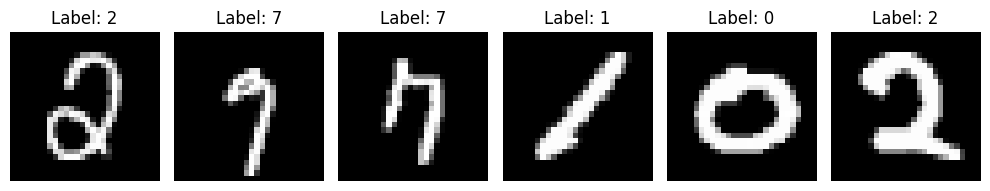

In [7]:
# Get one batch of real images
real_images, real_labels = next(iter(train_loader))

# Plot a few images from the batch
fig, axes = plt.subplots(1, 6, figsize=(10, 2))
for i in range(6):
    axes[i].imshow(real_images[i].squeeze(), cmap="gray")
    axes[i].set_title(f"Label: {real_labels[i].item()}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## Initialize models

In [ ]:
G = Generator(
    z_dim=config["latent_dim"],
    h_dim=config["g_hidden_dim"],
    x_dim=config["image_dim"],
).to(device)

D = Discriminator(
    x_dim=config["image_dim"],
    h_dim=config["d_hidden_dim"],
).to(device)

print(G)
print()
print(D)

## Define the loss function and optimizers

In [11]:
# Binary cross entropy loss for Vanilla GAN
criterion = nn.BCELoss()

# Separate optimizers for Generator and Discriminator
g_optimizer = optim.Adam(
    G.parameters(),
    lr=config["g_lr"],
    betas=config["betas"]
)

d_optimizer = optim.Adam(
    D.parameters(),
    lr=config["d_lr"],
    betas=config["betas"]
)

## Helper function to visualize generated images

In [12]:
# Display generated images inside the notebook
def show_generated_images(generator, latent_dim, num_images=16):
    generator.eval()

    with torch.no_grad():
        z = torch.randn(num_images, latent_dim, device=device)
        fake_images = generator(z).view(-1, 28, 28).cpu().numpy()

    fig, axes = plt.subplots(4, 4, figsize=(6, 6))
    for i, ax in enumerate(axes.flat):
        ax.imshow(fake_images[i], cmap="gray")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    generator.train()

## Helper function for W&B image logging

In [13]:
# Create a matplotlib figure for W&B image logging
def make_generated_figure(generator, latent_dim, num_images=16):
    generator.eval()

    with torch.no_grad():
        z = torch.randn(num_images, latent_dim, device=device)
        fake_images = generator(z).view(-1, 28, 28).cpu().numpy()

    fig, axes = plt.subplots(4, 4, figsize=(6, 6))
    for i, ax in enumerate(axes.flat):
        ax.imshow(fake_images[i], cmap="gray")
        ax.axis("off")

    plt.tight_layout()
    generator.train()
    return fig

## Helper function for saving final model

In [ ]:
def build_model_name(config, task_name="task1", file_ext="pt"):
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    return (
        f"{task_name}"
        f"_model-{config['model'].replace(' ', '_')}"
        f"_data-{config['dataset']}"
        f"_ep-{config['epochs']}"
        f"_bs-{config['batch_size']}"
        f"_glr-{config['g_lr']}"
        f"_dlr-{config['d_lr']}"
        f"_gh-{config['g_hidden_dim']}"
        f"_dh-{config['d_hidden_dim']}"
        f"_seed-{config['seed']}"
        f"_{timestamp}.{file_ext}"
    )

## Save checkpoints at selected epochs

In [15]:
# Optional helper for saving images at specific epochs
# You can reuse this cell if you want to save outputs at 5, 10, and 50 epochs

def save_generated_grid(generator, latent_dim, save_path, num_images=16):
    generator.eval()
    with torch.no_grad():
        z = torch.randn(num_images, latent_dim, device=device)
        fake_images = generator(z).view(-1, 28, 28).cpu().numpy()

    fig, axes = plt.subplots(4, 4, figsize=(6, 6))
    for i, ax in enumerate(axes.flat):
        ax.imshow(fake_images[i], cmap="gray")
        ax.axis("off")

    plt.tight_layout()
    plt.savefig(save_path, bbox_inches="tight")
    plt.close(fig)
    generator.train()

## Train the Vanilla GAN

In [ ]:
# Main training loop with epoch-level logging
# Also save generated samples at epochs 5, 10, 50, and 100

save_epochs = {5, 10, 50, 100}

for epoch in range(config["epochs"]):
    # Store batch losses for this epoch
    d_loss_list = []
    g_loss_list = []
    d_real_loss_list = []
    d_fake_loss_list = []

    for batch_idx, (real_images, _) in enumerate(train_loader):
        # Flatten images from [batch, 1, 28, 28] to [batch, 784]
        real_images = real_images.view(-1, config["image_dim"]).to(device, non_blocking=True)
        batch_size = real_images.size(0)

        # Create real and fake labels
        real_labels = torch.ones(batch_size, 1, device=device)
        fake_labels = torch.zeros(batch_size, 1, device=device)

        # =========================================================
        # 1) Train the Discriminator
        # =========================================================
        z = torch.randn(batch_size, config["latent_dim"], device=device)
        fake_images = G(z)

        d_real = D(real_images)
        d_fake = D(fake_images.detach())

        d_real_loss = criterion(d_real, real_labels)
        d_fake_loss = criterion(d_fake, fake_labels)
        d_loss = d_real_loss + d_fake_loss

        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

        # =========================================================
        # 2) Train the Generator
        # =========================================================
        z = torch.randn(batch_size, config["latent_dim"], device=device)
        fake_images = G(z)

        d_fake_for_g = D(fake_images)
        g_loss = criterion(d_fake_for_g, real_labels)

        g_optimizer.zero_grad()
        g_loss.backward()
        g_optimizer.step()

        # Store losses for epoch-level averaging
        d_loss_list.append(d_loss.item())
        g_loss_list.append(g_loss.item())
        d_real_loss_list.append(d_real_loss.item())
        d_fake_loss_list.append(d_fake_loss.item())

    # Compute average losses for the epoch
    avg_d_loss = np.mean(d_loss_list)
    avg_g_loss = np.mean(g_loss_list)
    avg_d_real_loss = np.mean(d_real_loss_list)
    avg_d_fake_loss = np.mean(d_fake_loss_list)

    # Print a clean epoch summary
    print(
        f"Epoch [{epoch + 1}/{config['epochs']}] | "
        f"D_loss: {avg_d_loss:.4f} | "
        f"G_loss: {avg_g_loss:.4f}"
    )

    # Log scalar metrics to W&B once per epoch
    wandb.log({
        "epoch": epoch + 1,
        "D_loss": avg_d_loss,
        "G_loss": avg_g_loss,
        "D_real_loss": avg_d_real_loss,
        "D_fake_loss": avg_d_fake_loss
    }, step=epoch + 1)

    # Log images to W&B every epoch if requested
    if (epoch + 1) % config["wandb_image_interval"] == 0:
        fig = make_generated_figure(G, config["latent_dim"], num_images=16)

        wandb.log({
            "generated_samples": wandb.Image(fig, caption=f"Epoch {epoch + 1}")
        }, step=epoch + 1)

        # Show images in Jupyter only every few epochs
        if (epoch + 1) % config["jupyter_plot_interval"] == 0:
            plt.show()

        plt.close(fig)

    # Save generated samples locally at selected epochs
    if (epoch + 1) in save_epochs:
        save_path = gc.OUT_DIR / f"task1_epoch_{epoch + 1}.png"
        save_generated_grid(
            generator=G,
            latent_dim=config["latent_dim"],
            save_path=save_path,
            num_images=16
        )
        print(f"Saved generated samples to: {save_path}")

## Save trained models

In [ ]:
# Save a full training checkpoint
checkpoint_name = build_model_name(config, task_name="task1")
checkpoint_path = gc.MODELS_DIR / checkpoint_name

torch.save({
    "task": "Task 1",
    "model_type": config["model"],
    "dataset": config["dataset"],
    "epoch": config["epochs"],
    "generator_state_dict": G.state_dict(),
    "discriminator_state_dict": D.state_dict(),
    "g_optimizer_state_dict": g_optimizer.state_dict(),
    "d_optimizer_state_dict": d_optimizer.state_dict(),
    "config": config,
    "device_used": str(device),
}, checkpoint_path)

print(f"Checkpoint saved to: {checkpoint_path}")

In [ ]:
# Save Generator weights only
generator_name = build_model_name(config, task_name="task1_generator")
generator_path = gc.MODELS_DIR / generator_name

torch.save(G.state_dict(), generator_path)

print(f"Generator weights saved to: {generator_path}")

## Display final generated samples

In [ ]:
# Show final generated images after training
show_generated_images(G, config["latent_dim"], num_images=16)

## Finish the W&B run

In [ ]:
wandb.finish()